<a href="https://colab.research.google.com/github/Imesh-Isuranga/ME-422-Group-B1/blob/main/Controls/E_20_028_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## E/20/028 - Rigid Body PID Control

# Task#1

### Twin rotor system dynamic model

*Image Credits: Bhashitha Maduranga Nawaratne bhashitha614@gmail.com*

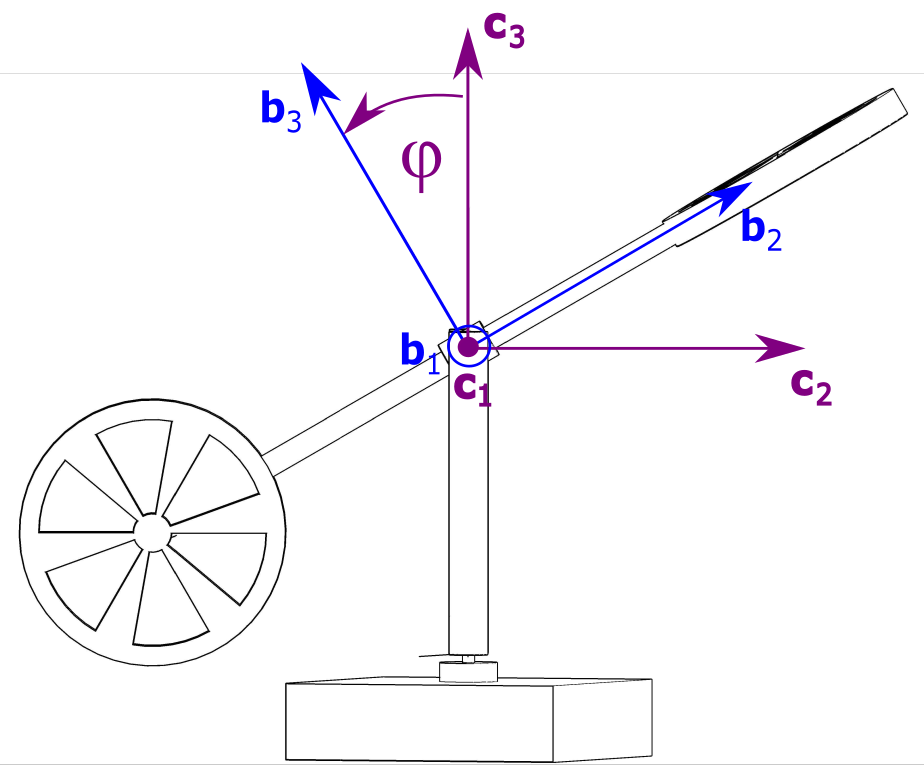

Show that the twin rotor system shown above can be modelled by

\begin{align}
\dot{R}&=\widehat{\omega}R,\\
\dot{\pi}&=\tau^e+\tau^u,
\end{align}
where
\begin{align}
\omega &=(\mathbb{I}^R)^{-1}\pi,
\end{align}
Here we have split the force and control moments into unmanipulatable and manipulatable (control) part. The manipulatable (control) part will be denoted by a superscript $u$ and takes the form

\begin{align*}
\tau^u &=R\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos{\alpha} & -\cos{\beta}\\
\sin{\alpha} & -\sin{\beta}
\end{bmatrix}
\begin{bmatrix}
u_1\\ u_2
\end{bmatrix}
\end{align*}
and the constriant moment that prevents the rotation of the device about $\mathbb{b}_2$ axis is
\begin{align}
\tau^e=R\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
\end{align}
with $T_2$ given by
\begin{align}
T_2&=e_2^T \left(\Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega}
\right)
\end{align}
where $\Omega = R^T\omega$.

In [2]:
R_simplified = simplify(R)
print("Simplified Rotation Matrix R:")
R_simplified

Simplified Rotation Matrix R:


Matrix([
[-sin(alpha)*sin(theta)*cos(phi) + cos(alpha)*cos(theta), -(sin(alpha)*cos(phi)*cos(theta) + sin(theta)*cos(alpha))*cos(gamma) + sin(alpha)*sin(gamma)*sin(phi), (sin(alpha)*cos(phi)*cos(theta) + sin(theta)*cos(alpha))*sin(gamma) + sin(alpha)*sin(phi)*cos(gamma)],
[ sin(alpha)*cos(theta) + sin(theta)*cos(alpha)*cos(phi), -(sin(alpha)*sin(theta) - cos(alpha)*cos(phi)*cos(theta))*cos(gamma) - sin(gamma)*sin(phi)*cos(alpha), (sin(alpha)*sin(theta) - cos(alpha)*cos(phi)*cos(theta))*sin(gamma) - sin(phi)*cos(alpha)*cos(gamma)],
[                                    sin(phi)*sin(theta),                                                  sin(gamma)*cos(phi) + sin(phi)*cos(gamma)*cos(theta),                                                -sin(gamma)*sin(phi)*cos(theta) + cos(gamma)*cos(phi)]])

# Task 1: Twin Rotor System Dynamic Model

## 1. Kinematics of the Rigid Body
The orientation of the twin rotor system is represented by the rotation matrix $R \in \text{SO}(3)$, which maps the body-fixed frame $\mathcal{B}$ to the inertial frame $\mathcal{I}$. The spatial angular velocity $\omega$ is related to the rate of change of the rotation matrix by:

\begin{equation}
\dot{R} = \widehat{\omega} R
\end{equation}

where $\widehat{\omega}$ is the skew-symmetric matrix such that $\widehat{\omega} v = \omega \times v$ for any vector $v$. The relationship between the spatial angular velocity $\omega$ and the body-fixed angular velocity $\Omega$ is given by:

\begin{equation}
\Omega = R^T \omega \quad \text{and} \quad \omega = R \Omega
\end{equation}

## 2. Angular Momentum and Euler's Equation
Let $\mathbb{I}$ be the constant inertia tensor of the twin rotor system defined in the body-fixed frame. The angular momentum in the body frame is denoted by $\Pi = \mathbb{I} \Omega$. The spatial angular momentum $\pi$ is the transformation of $\Pi$ into the inertial frame:

\begin{equation}
\pi = R \Pi = R \mathbb{I} \Omega = R \mathbb{I} R^T \omega
\end{equation}

According to Euler's laws of motion, the rate of change of angular momentum in the inertial frame is equal to the total external torque $\tau$:

\begin{equation}
\dot{\pi} = \tau
\end{equation}

In this system, the total torque is sum of the control (manipulatable) torque $\tau^u$ and the constraint moment $\tau^e$:

\begin{equation}
\dot{\pi} = \tau^u + \tau^e
\end{equation}

The angular velocity can be expressed in terms of the spatial angular momentum as:

\begin{equation}
\omega = (R \mathbb{I} R^T)^{-1} \pi
\end{equation}

## 3. Control Torque Model
The manipulatable part of the torque, $\tau^u$, is generated by the thrust of the rotors. For a twin rotor MIMO system (TRMS), the thrust vectors produce moments that depend on the geometry and the tilt angles. Given the projection into the spatial frame, the control torque is modeled as:

\begin{equation}
\tau^u = R \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos{\alpha} & -\cos{\beta} \\ \sin{\alpha} & -\sin{\beta} \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}
\end{equation}

where $u_1$ and $u_2$ are the control inputs corresponding to the rotor thrusts, and $\alpha, \beta$ are the angles defining the thrust directions relative to the body axes.

## 4. Constraint Torque and $T_2$ Derivation
The twin rotor system is often constrained to rotate only about specific axes (e.g., pitch and yaw). If the device is constrained from rotating about its own $\mathbf{b}_2$ axis, a constraint torque $\tau^e$ must exist to satisfy this kinematic constraint. In the body frame, the dynamic equations are:

\begin{equation}
\mathbb{I} \dot{\Omega} + \Omega \times \mathbb{I} \Omega = T^u_{\mathcal{B}} + T^e_{\mathcal{B}}
\end{equation}

For a constraint that prevents rotation about the $\mathbf{b}_2$ axis, the constraint moment in the body frame is $T^e_{\mathcal{B}} = \begin{bmatrix} 0 & T_2 & 0 \end{bmatrix}^T$. Projecting the dynamic equation onto the $e_2$ basis vector, we find:

\begin{equation}
T_2 = e_2^T \left( \mathbb{I} \dot{\Omega} + \Omega \times \mathbb{I} \Omega \right)
\end{equation}

The spatial constraint torque is then:

\begin{equation}
\tau ^e = R \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix}
\end{equation}

Thus, we have shown that the twin rotor system is modeled by the specified equations of motion.

In [1]:
import sympy
from sympy import symbols, Matrix, sin, cos, simplify

# Define symbolic angles (following lecturer's example)
alpha, theta, phi, gamma = symbols('alpha theta phi gamma')

# Define elementary rotation matrices
def R1(q):
    return Matrix([[1, 0, 0],
                  [0, cos(q), -sin(q)],
                  [0, sin(q), cos(q)]])

def R3(q):
    return Matrix([[cos(q), -sin(q), 0],
                  [sin(q), cos(q), 0],
                  [0, 0, 1]])

# Total rotation matrix R from Body to Inertial
R = R3(alpha) * R1(phi) * R3(theta) * R1(gamma)

# Define Inertia Tensor in body frame
I1, I2, I3 = symbols('I1 I2 I3')
II = Matrix([[I1, 0, 0],
             [0, I2, 0],
             [0, 0, I3]])

print("Symbolic variables and rotation matrix R defined.")
R

Symbolic variables and rotation matrix R defined.


Matrix([
[-sin(alpha)*sin(theta)*cos(phi) + cos(alpha)*cos(theta), (-sin(alpha)*cos(phi)*cos(theta) - sin(theta)*cos(alpha))*cos(gamma) + sin(alpha)*sin(gamma)*sin(phi), -(-sin(alpha)*cos(phi)*cos(theta) - sin(theta)*cos(alpha))*sin(gamma) + sin(alpha)*sin(phi)*cos(gamma)],
[ sin(alpha)*cos(theta) + sin(theta)*cos(alpha)*cos(phi), (-sin(alpha)*sin(theta) + cos(alpha)*cos(phi)*cos(theta))*cos(gamma) - sin(gamma)*sin(phi)*cos(alpha), -(-sin(alpha)*sin(theta) + cos(alpha)*cos(phi)*cos(theta))*sin(gamma) - sin(phi)*cos(alpha)*cos(gamma)],
[                                    sin(phi)*sin(theta),                                                  sin(gamma)*cos(phi) + sin(phi)*cos(gamma)*cos(theta),                                                  -sin(gamma)*sin(phi)*cos(theta) + cos(gamma)*cos(phi)]])